# 04 Validation and Interpretation
## 검증 및 해석

Model result checks, robustness, and interpretation figures.


## Setup
### 설정


In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

candidate_processed_dirs = []
if os.environ.get("XENTE_PROCESSED_DIR"):
    candidate_processed_dirs.append(Path(os.environ["XENTE_PROCESSED_DIR"]))
candidate_processed_dirs.extend([
    Path.cwd().parent / "outputs" / "tables",
    Path.cwd() / "outputs" / "tables",
    Path.cwd().parent / "processed",
    Path.cwd() / "processed",
    Path("/content/drive/MyDrive/XENTE DATA/processed"),
])

PROCESSED_DIR = next(
    (path for path in candidate_processed_dirs if (path / "train_model_table_v1.csv").exists()),
    candidate_processed_dirs[-1],
)
MODEL_TABLE_PATH = PROCESSED_DIR / "train_model_table_v1.csv"
FIGURE_DIR = (
    Path.cwd().parent / "outputs" / "figures"
    if (Path.cwd().parent / "outputs").exists()
    else Path.cwd() / "outputs" / "figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_FIGS = True


def save_fig(filename):
    if SAVE_FIGS:
        path = FIGURE_DIR / filename
        plt.savefig(path, dpi=180, bbox_inches="tight")


def load_first_existing(paths, label):
    for path in paths:
        path = Path(path)
        if path.exists():
            return pd.read_csv(path)
    return None


def default_rate_table(data, group_col):
    output = (
        data
        .groupby(group_col, observed=False)
        .agg(
            loan_count=("IsDefaulted", "count"),
            default_count=("IsDefaulted", "sum"),
            default_rate=("IsDefaulted", "mean"),
        )
        .reset_index()
    )
    output["default_rate_pct"] = output["default_rate"] * 100
    return output


def label_bar_patches(ax, fmt="{:.1f}%", padding_ratio=0.02, fontsize=9):
    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * padding_ratio
    for patch in ax.patches:
        height = patch.get_height()
        if not np.isfinite(height):
            continue
        x = patch.get_x() + patch.get_width() / 2
        ax.text(x, height + offset, fmt.format(height), ha="center", va="bottom", fontsize=fontsize)


base_color = "#6B8EAD"
highlight_color = "#C87A7E"
retail_color = "#E76F51"
neutral_color = "#8FA6B2"


In [2]:
model_table = pd.read_csv(MODEL_TABLE_PATH)
model_table["IsDefaulted"] = model_table["IsDefaulted"].astype(int)

if "IssuedDateLoan" in model_table.columns:
    model_table["IssuedDateLoan"] = pd.to_datetime(model_table["IssuedDateLoan"], errors="coerce")
if "issue_month" not in model_table.columns and "IssuedDateLoan" in model_table.columns:
    model_table["issue_month"] = model_table["IssuedDateLoan"].dt.month
if "issue_weekday" not in model_table.columns and "IssuedDateLoan" in model_table.columns:
    model_table["issue_weekday"] = model_table["IssuedDateLoan"].dt.day_name()

prior_txn_map = {
    "no_prior_txn": "No prior transaction",
    "low_txn_history": "Low transaction history",
    "medium_txn_history": "Medium transaction history",
    "high_txn_history": "High transaction history",
}
product_map = {
    "airtime": "Airtime",
    "data_bundles": "Data Bundles",
    "financial_services": "Financial Services",
    "movies": "Movies",
    "retail": "Retail",
    "tv": "TV",
    "utility_bill": "Utility Bill",
}
issuer_map = {
    "InvestorId_1": "Loan Issuer 1",
    "InvestorId_2": "Loan Issuer 2",
    "InvestorId_3": "Loan Issuer 3",
}
service_flow_map = {
    "SubscriptionId_1": "Service Flow ID 1",
    "SubscriptionId_4": "Service Flow ID 4",
    "SubscriptionId_5": "Service Flow ID 5",
    "SubscriptionId_6": "Service Flow ID 6",
    "SubscriptionId_7": "Service Flow ID 7",
}

model_table["repayment_group"] = np.where(
    model_table["repayment_history_segment"].eq("cold_start_no_known_repayment"),
    "No prior repayment history",
    "Prior repayment history",
)
model_table["transaction_history_group"] = (
    model_table["prior_txn_segment"].map(prior_txn_map).fillna(model_table["prior_txn_segment"])
)
txn_group_order = [
    "No prior transaction",
    "Low transaction history",
    "Medium transaction history",
    "High transaction history",
]
model_table["transaction_history_group"] = pd.Categorical(
    model_table["transaction_history_group"],
    categories=txn_group_order,
    ordered=True,
)
model_table["product_category_label"] = (
    model_table["ProductCategory"].map(product_map).fillna(model_table["ProductCategory"])
)
model_table["loan_issuer_label"] = (
    model_table["InvestorId"].map(issuer_map).fillna(model_table["InvestorId"])
)
model_table["service_flow_label"] = (
    model_table["SubscriptionId"].map(service_flow_map).fillna(model_table["SubscriptionId"])
)
if "issue_month" in model_table.columns:
    model_table["issue_month_label"] = "Month " + model_table["issue_month"].astype("Int64").astype(str)

cold_start = model_table[
    model_table["repayment_history_segment"].eq("cold_start_no_known_repayment")
].copy()

display(pd.DataFrame([{
    "total_loans": len(model_table),
    "total_defaults": int(model_table["IsDefaulted"].sum()),
    "cold_start_loans": len(cold_start),
    "cold_start_defaults": int(cold_start["IsDefaulted"].sum()),
}]))


,total_loans,total_defaults,cold_start_loans,cold_start_defaults
0,1153,71,385,59


In [3]:
TRACK_ORDER = [
    "Operational Model",
    "Product/Operation Removed Model",
    "Behavior-only Validation Model",
]
TRACK_DISPLAY = {
    "Operational Model": "Operational\nModel",
    "Product/Operation Removed Model": "Product/Operation\nRemoved Model",
    "Behavior-only Validation Model": "Behavior-only\nValidation Model",
}


def track_label(text):
    text = str(text)
    if any(key in text for key in ["A_operational", "A_", "Track A", "Operational"]):
        return "Operational Model"
    if any(key in text for key in ["B_ablation", "B_", "Track B", "Ablation"]):
        return "Product/Operation Removed Model"
    if any(key in text for key in ["C_strict", "C_", "Track C", "Strict"]):
        return "Behavior-only Validation Model"
    return text[:35]


def model_label(text):
    text = str(text)
    if "LR" in text:
        return "LR-WOE"
    if "LightGBM" in text:
        return "LightGBM"
    return text


def feature_group_label(group):
    mapping = {
        "value": "Amount",
        "time_subscription": "Time / Service Flow",
        "product_investor": "Product / Loan Issuer",
        "txn_presence_recency_count": "Transaction: Activity / Recency / Count",
        "txn_amount": "Transaction: Amount",
        "txn_diversity_category": "Transaction: Diversity",
        "Transaction": "Transaction Behavior",
        "Current Value": "Amount",
        "Time / Subscription": "Time / Service Flow",
        "Product / Investor": "Product / Loan Issuer",
    }
    return mapping.get(str(group), str(group))


def find_score_band_pair(score_band_data):
    prediction_cols = score_band_data["prediction_col"].dropna().unique().tolist()

    def has_all(text, keywords):
        text = text.lower()
        return all(keyword.lower() in text for keyword in keywords)

    def has_any(text, keywords):
        text = text.lower()
        return any(keyword.lower() in text for keyword in keywords)

    basic_candidates = [
        col for col in prediction_cols
        if has_all(col, ["A_operational", "A0_Basic", "LightGBM"])
    ]
    transaction_candidates = [
        col for col in prediction_cols
        if has_all(col, ["A_operational", "LightGBM"])
        and has_any(col, ["A2", "Txn", "Transaction", "Compact"])
        and not has_any(col, ["A0_Basic"])
    ]
    if basic_candidates and transaction_candidates:
        return basic_candidates[0], transaction_candidates[0]
    return None, None


## Incremental value
### 추가 성능 가치


,validation_track,model,base_PR_AUC,new_PR_AUC,delta_PR_AUC,base_Top10_Capture,new_Top10_Capture,delta_Top10_Capture
2,Operational Model,LR-WOE,0.719389,0.692569,-0.026820,0.525424,0.525424,0.000000
3,Operational Model,LightGBM,0.668150,0.681224,0.013074,0.491525,0.508475,0.016949
4,Product/Operation Removed Model,LR-WOE,0.717890,0.695615,-0.022275,0.525424,0.525424,0.000000
5,Product/Operation Removed Model,LightGBM,0.660613,0.687537,0.026924,0.491525,0.508475,0.016949
0,Behavior-only Validation Model,LR-WOE,0.700252,0.708068,0.007816,0.525424,0.525424,0.000000
1,Behavior-only Validation Model,LightGBM,0.647855,0.664273,0.016418,0.508475,0.508475,0.000000


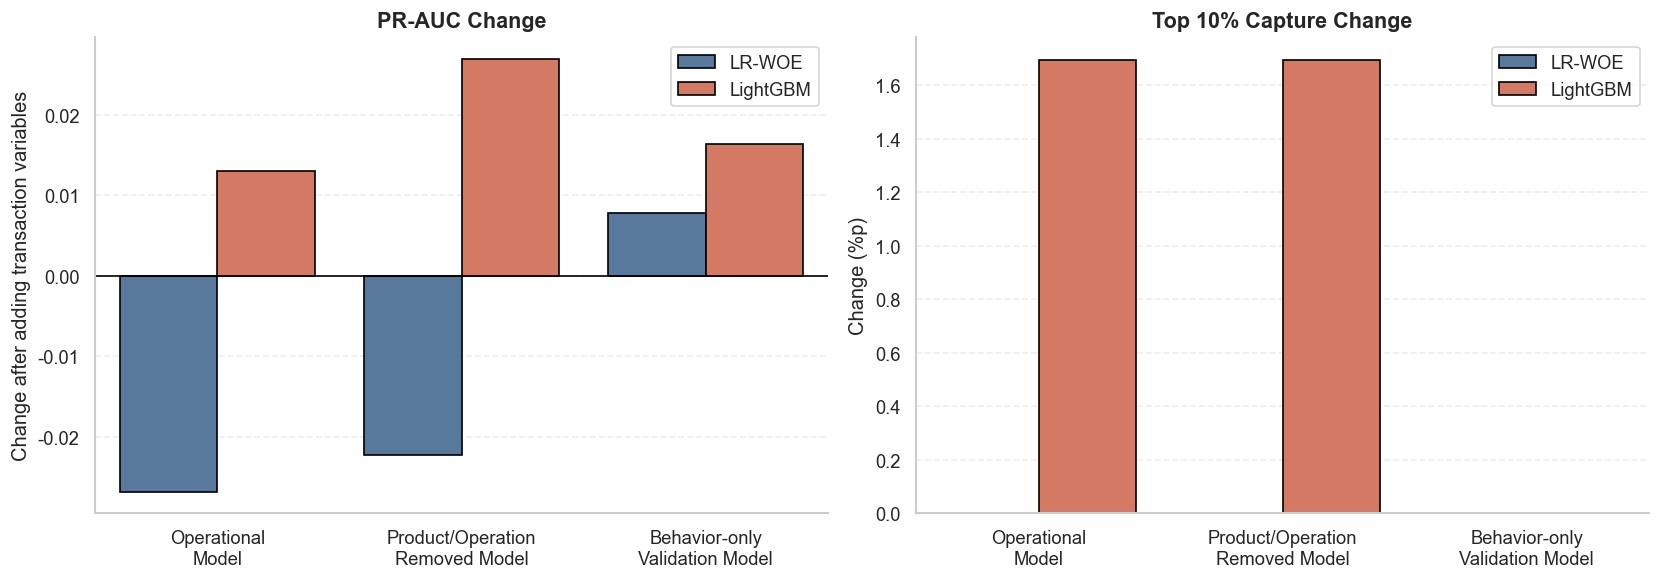

In [4]:
delta_df = load_first_existing(
    [
        PROCESSED_DIR / "modeling_validation" / "cold_start_transaction_incremental_value_delta.csv",
        PROCESSED_DIR / "additional_modeling_diagnostics" / "cold_start_transaction_incremental_value_delta.csv",
        PROCESSED_DIR / "cold_start_modeling_outputs" / "cold_start_transaction_incremental_value_delta.csv",
    ],
    "Transaction incremental value",
)

if delta_df is None:
    print("Transaction incremental value result file was not found. Run notebooks/03_modeling_validation.ipynb first.")
else:

    plot_delta = delta_df.copy()
    track_text = (
        plot_delta["track"] if "track" in plot_delta.columns
        else plot_delta["track_desc"] if "track_desc" in plot_delta.columns
        else plot_delta["comparison"] if "comparison" in plot_delta.columns
        else pd.Series([""] * len(plot_delta))
    )
    plot_delta["validation_track"] = track_text.astype(str).apply(track_label)
    plot_delta["model"] = plot_delta["model_kind"].apply(model_label)

    if "new_feature_set" in plot_delta.columns:
        def feature_priority(feature_set):
            text = str(feature_set).lower()
            if "compact" in text:
                return 0
            if "transaction" in text and "mini" not in text and "full" not in text:
                return 1
            if "mini" in text:
                return 2
            if "full" in text:
                return 3
            return 4

        plot_delta["priority"] = plot_delta["new_feature_set"].apply(feature_priority)
        plot_delta = (
            plot_delta
            .sort_values(["validation_track", "model", "priority"])
            .groupby(["validation_track", "model"], as_index=False)
            .first()
        )

    if "delta_PR_AUC" not in plot_delta.columns:
        plot_delta["delta_PR_AUC"] = plot_delta["new_PR_AUC"] - plot_delta["base_PR_AUC"]
    if "delta_Top10_Capture" not in plot_delta.columns:
        plot_delta["delta_Top10_Capture"] = plot_delta["new_Top10_Capture"] - plot_delta["base_Top10_Capture"]
    plot_delta["delta_Top10_Capture_pctp"] = plot_delta["delta_Top10_Capture"] * 100
    plot_delta["validation_track"] = pd.Categorical(plot_delta["validation_track"], TRACK_ORDER, ordered=True)
    plot_delta["validation_track_display"] = plot_delta["validation_track"].astype(str).map(TRACK_DISPLAY)
    plot_delta = plot_delta.sort_values(["validation_track", "model"])

    display(plot_delta[[
        "validation_track", "model", "base_PR_AUC", "new_PR_AUC", "delta_PR_AUC",
        "base_Top10_Capture", "new_Top10_Capture", "delta_Top10_Capture",
    ]])

    fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.0))
    for ax, y_col, title, y_label in [
        (axes[0], "delta_PR_AUC", "PR-AUC Change", "Change after adding transaction variables"),
        (axes[1], "delta_Top10_Capture_pctp", "Top 10% Capture Change", "Change (%p)"),
    ]:
        sns.barplot(
            data=plot_delta,
            x="validation_track_display",
            y=y_col,
            hue="model",
            palette={"LR-WOE": "#4C78A8", "LightGBM": "#E76F51"},
            edgecolor="black",
            linewidth=1,
            ax=ax,
        )
        ax.axhline(0, color="black", linewidth=1)
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel(y_label)
        ax.legend(title="")
        ax.grid(axis="y", linestyle="--", alpha=0.35)
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    save_fig("main_08_transaction_incremental_value.png")
    plt.show()


## Score band capture
### 점수 구간 포착률


,Model,Score Band,Loan Count,Default Count,Default Rate (%),Default Capture Rate (%)
10,Basic Model,Band 1\nHigh Risk,77,51,66.233766,86.440678
15,Transaction-added Model,Band 1\nHigh Risk,77,52,67.532468,88.135593
11,Basic Model,Band 2,77,3,3.896104,5.084746
16,Transaction-added Model,Band 2,77,3,3.896104,5.084746
12,Basic Model,Band 3,77,1,1.298701,1.694915
17,Transaction-added Model,Band 3,77,3,3.896104,5.084746
13,Basic Model,Band 4,77,3,3.896104,5.084746
18,Transaction-added Model,Band 4,77,1,1.298701,1.694915
14,Basic Model,Band 5\nLow Risk,77,1,1.298701,1.694915
19,Transaction-added Model,Band 5\nLow Risk,77,0,0.000000,0.000000


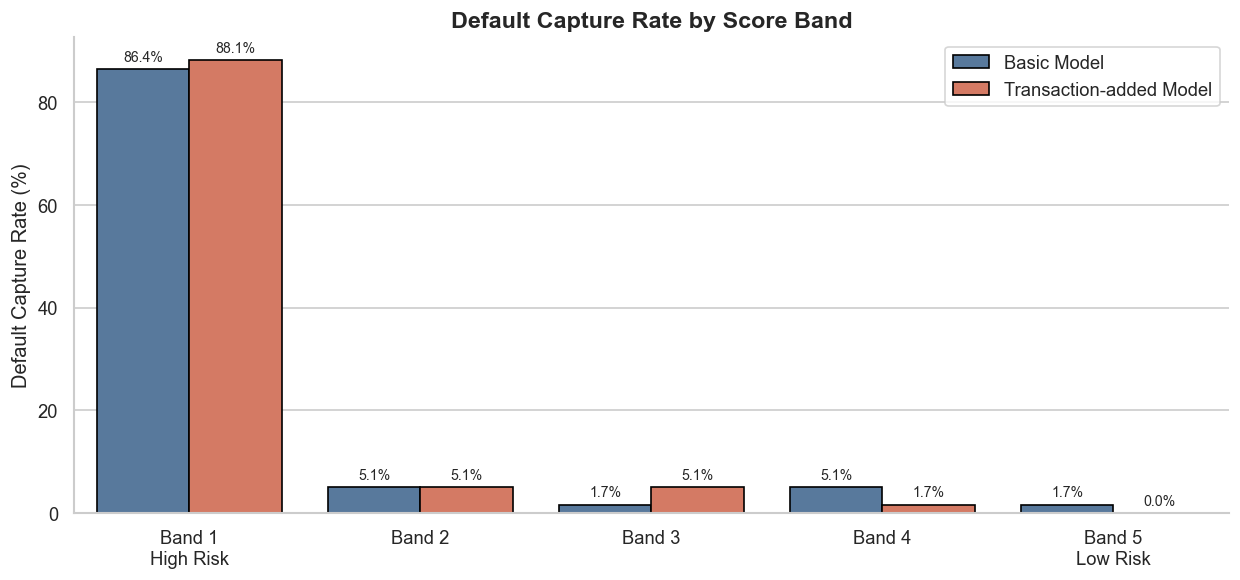

In [5]:
score_band_candidates = [
    PROCESSED_DIR / "modeling_validation" / "cold_start_score_band_all.csv",
    PROCESSED_DIR / "final_explainability_outputs" / "score_band_all_selected_models.csv",
    PROCESSED_DIR / "cold_start_modeling_outputs" / "cold_start_score_band_all.csv",
    PROCESSED_DIR / "additional_modeling_diagnostics" / "cold_start_score_band_all_compact_models.csv",
]
score_band_df = None
basic_score_col = None
transaction_score_col = None
for path in score_band_candidates:
    if path.exists():
        candidate = pd.read_csv(path)
        basic_score_col, transaction_score_col = find_score_band_pair(candidate)
        if basic_score_col and transaction_score_col:
            score_band_df = candidate
            break

if score_band_df is None:
    print("A score band file with both basic and transaction-added models was not found. Run notebooks/03_modeling_validation.ipynb first.")
else:

    score_plot = score_band_df[
        score_band_df["prediction_col"].isin([basic_score_col, transaction_score_col])
    ].copy()
    if "default_rate_pct" not in score_plot.columns and "default_rate" in score_plot.columns:
        score_plot["default_rate_pct"] = score_plot["default_rate"] * 100
    if "capture_rate_pct" not in score_plot.columns and "capture_rate" in score_plot.columns:
        score_plot["capture_rate_pct"] = score_plot["capture_rate"] * 100

    score_plot["model"] = score_plot["prediction_col"].map({
        basic_score_col: "Basic Model",
        transaction_score_col: "Transaction-added Model",
    })
    score_plot["band_no"] = score_plot["score_band"].astype(str).str.extract(r"Band\s*(\d+)")[0].astype(int)
    band_label = {1: "Band 1\nHigh Risk", 2: "Band 2", 3: "Band 3", 4: "Band 4", 5: "Band 5\nLow Risk"}
    score_plot["score_band_label"] = score_plot["band_no"].map(band_label)
    score_plot["score_band_label"] = pd.Categorical(score_plot["score_band_label"], [band_label[i] for i in range(1, 6)], ordered=True)
    score_plot["model"] = pd.Categorical(score_plot["model"], ["Basic Model", "Transaction-added Model"], ordered=True)
    score_plot = score_plot.sort_values(["score_band_label", "model"])

    display(score_plot[[
        "model", "score_band_label", "count", "default_count", "default_rate_pct", "capture_rate_pct",
    ]].rename(columns={
        "model": "Model",
        "score_band_label": "Score Band",
        "count": "Loan Count",
        "default_count": "Default Count",
        "default_rate_pct": "Default Rate (%)",
        "capture_rate_pct": "Default Capture Rate (%)",
    }))

    fig, ax = plt.subplots(figsize=(10.5, 5.0))
    sns.barplot(
        data=score_plot,
        x="score_band_label",
        y="capture_rate_pct",
        hue="model",
        palette={"Basic Model": "#4C78A8", "Transaction-added Model": "#E76F51"},
        edgecolor="black",
        linewidth=1,
        ax=ax,
    )
    ax.set_title("Default Capture Rate by Score Band", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Default Capture Rate (%)")
    for container in ax.containers:
        labels = [f"{bar.get_height():.1f}%" if not np.isnan(bar.get_height()) else "" for bar in container]
        ax.bar_label(container, labels=labels, padding=3, fontsize=8.5)
    ax.legend(title="")
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    save_fig("main_10_score_band_capture_rate.png")
    plt.show()


## Transaction count quantile robustness
### 거래 횟수 분위수 강건성


,Transaction Count Quantile,Loan Count,Default Count,default_rate,Default Rate (%)
0,No prior transaction,217,53,0.244240,24.423963
1,Q1 Lowest,44,1,0.022727,2.272727
2,Q2,40,1,0.025000,2.500000
3,Q3,42,4,0.095238,9.523810
4,Q4 Highest,42,0,0.000000,0.000000


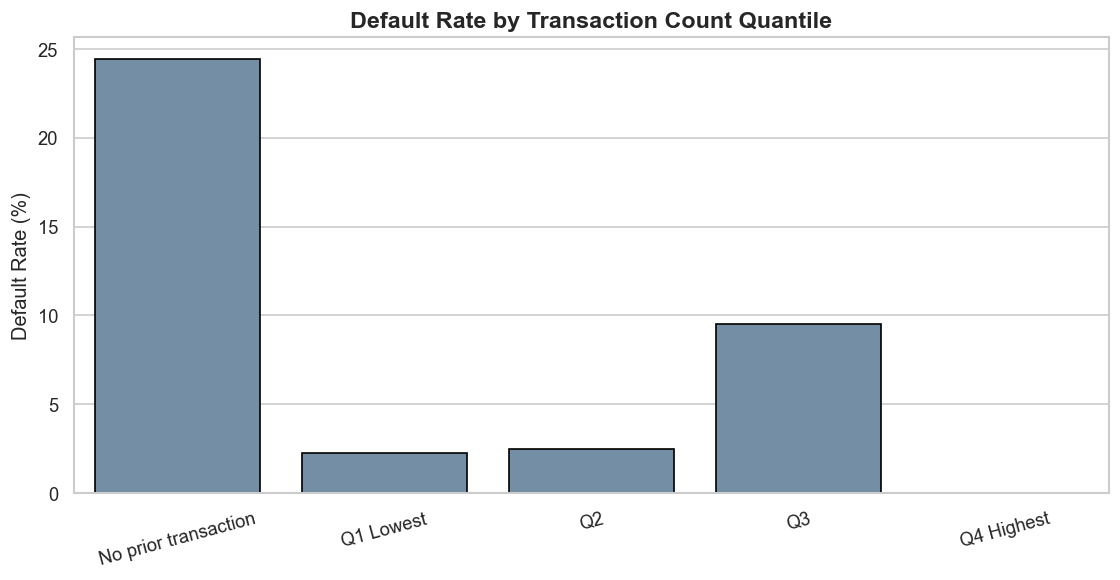

In [6]:
quantile_data = cold_start.copy()
positive_counts = quantile_data.loc[quantile_data["prior_txn_count_all"].gt(0), "prior_txn_count_all"]
quantile_data["transaction_count_quantile"] = "No prior transaction"
if positive_counts.nunique() >= 4:
    quantile_data.loc[quantile_data["prior_txn_count_all"].gt(0), "transaction_count_quantile"] = pd.qcut(
        positive_counts,
        q=4,
        labels=["Q1 Lowest", "Q2", "Q3", "Q4 Highest"],
        duplicates="drop",
    ).astype(str)

quantile_order = ["No prior transaction", "Q1 Lowest", "Q2", "Q3", "Q4 Highest"]
quantile_data["transaction_count_quantile"] = pd.Categorical(
    quantile_data["transaction_count_quantile"],
    categories=quantile_order,
    ordered=True,
)
quantile_summary = default_rate_table(quantile_data, "transaction_count_quantile")
display(quantile_summary.rename(columns={
    "transaction_count_quantile": "Transaction Count Quantile",
    "loan_count": "Loan Count",
    "default_count": "Default Count",
    "default_rate_pct": "Default Rate (%)",
}))

fig, ax = plt.subplots(figsize=(9.5, 5.0))
sns.barplot(
    data=quantile_summary,
    x="transaction_count_quantile",
    y="default_rate_pct",
    color=base_color,
    edgecolor="black",
    linewidth=1,
    ax=ax,
)
ax.set_title("Default Rate by Transaction Count Quantile", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
save_fig("appendix_03_transaction_count_quantile_robustness.png")
plt.show()


## Repeat customer check
### 반복 고객 확인


,customer_type,customer_count,loan_count,default_count,default_rate_pct
0,Single-loan Customer,179,179,57,31.843575
1,Repeat Customer,60,206,2,0.970874


,CustomerId,Loan Count,Default Count,Default Rate,is_repeat_customer
87,CustomerId_263,5,1,0.2,True
64,CustomerId_223,2,1,0.5,True
1,CustomerId_10,1,1,1.0,False
8,CustomerId_116,1,1,1.0,False
9,CustomerId_117,1,1,1.0,False
13,CustomerId_124,1,1,1.0,False
17,CustomerId_134,1,1,1.0,False
21,CustomerId_14,1,1,1.0,False
22,CustomerId_140,1,1,1.0,False
29,CustomerId_154,1,1,1.0,False


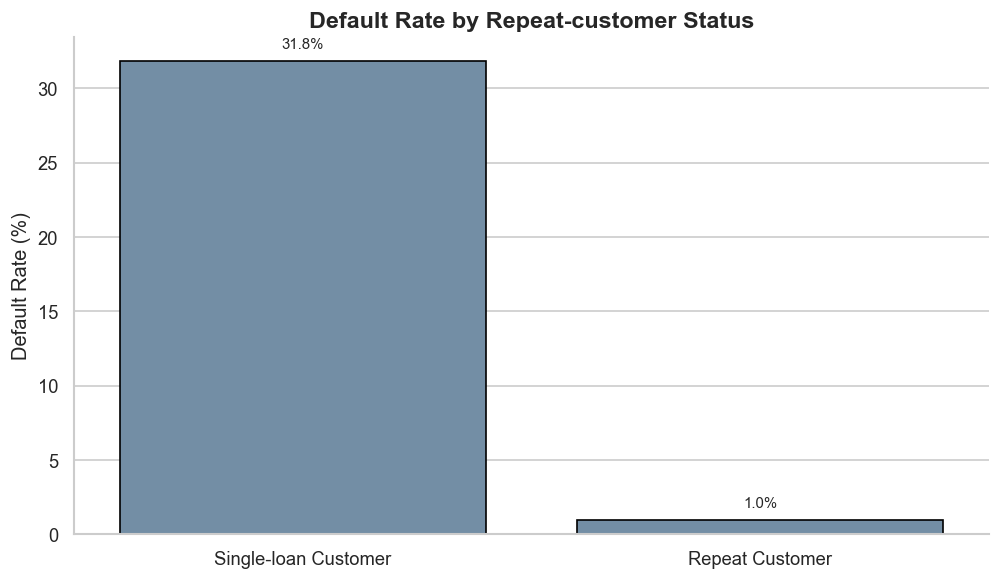

In [7]:
customer_summary = (
    cold_start
    .groupby("CustomerId")
    .agg(
        loan_count=("IsDefaulted", "count"),
        default_count=("IsDefaulted", "sum"),
        default_rate=("IsDefaulted", "mean"),
    )
    .reset_index()
)
customer_summary["is_repeat_customer"] = customer_summary["loan_count"].gt(1)

repeat_summary = (
    customer_summary
    .groupby("is_repeat_customer")
    .agg(
        customer_count=("CustomerId", "count"),
        loan_count=("loan_count", "sum"),
        default_count=("default_count", "sum"),
    )
    .reset_index()
)
repeat_summary["default_rate_pct"] = repeat_summary["default_count"] / repeat_summary["loan_count"] * 100
repeat_summary["customer_type"] = np.where(repeat_summary["is_repeat_customer"], "Repeat Customer", "Single-loan Customer")

top_customers = customer_summary.sort_values(["default_count", "loan_count"], ascending=False).head(20)
display(repeat_summary[["customer_type", "customer_count", "loan_count", "default_count", "default_rate_pct"]])
display(top_customers.rename(columns={
    "loan_count": "Loan Count",
    "default_count": "Default Count",
    "default_rate": "Default Rate",
}))

fig, ax = plt.subplots(figsize=(8.5, 5.0))
sns.barplot(
    data=repeat_summary,
    x="customer_type",
    y="default_rate_pct",
    color=base_color,
    edgecolor="black",
    linewidth=1,
    ax=ax,
)
ax.set_title("Default Rate by Repeat-customer Status", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Default Rate (%)")
label_bar_patches(ax)
sns.despine(left=False, bottom=False)
plt.tight_layout()
save_fig("appendix_02_repeat_customer_effect.png")
plt.show()


## SHAP detail
### SHAP 상세


In [8]:
shap_detail_df = load_first_existing(
    [
        PROCESSED_DIR / "final_explainability_outputs" / "representative_lgbm_shap_feature.csv",
        PROCESSED_DIR / "final_explainability_outputs" / "representative_lgbm_shap_detail.csv",
    ],
    "Detailed SHAP",
)
shap_group_df = load_first_existing(
    [PROCESSED_DIR / "final_explainability_outputs" / "representative_lgbm_shap_group.csv"],
    "SHAP group contribution",
)

if shap_group_df is not None:
    value_col = next((col for col in ["mean_abs_shap", "importance_gain", "importance_split"] if col in shap_group_df.columns), None)
    if value_col:
        shap_group_plot = shap_group_df.copy()
        shap_group_plot["feature_group_label"] = shap_group_plot["feature_group"].apply(feature_group_label)
        shap_group_plot = shap_group_plot.sort_values(value_col, ascending=True)
        display(shap_group_plot[["feature_group_label", value_col]].rename(columns={
            "feature_group_label": "Feature Group",
            value_col: "SHAP Contribution",
        }))

        fig, ax = plt.subplots(figsize=(8.5, 5.0))
        colors = ["#E76F51" if "Transaction" in group else neutral_color for group in shap_group_plot["feature_group_label"]]
        ax.barh(shap_group_plot["feature_group_label"], shap_group_plot[value_col], color=colors, edgecolor="black", linewidth=0.8)
        ax.set_title("SHAP Contribution by Feature Group", fontsize=14, fontweight="bold")
        ax.set_xlabel("Mean |SHAP|")
        ax.set_ylabel("")
        ax.grid(axis="x", linestyle="--", alpha=0.35)
        plt.tight_layout()
        save_fig("appendix_04_shap_group_contribution.png")
        plt.show()

if shap_detail_df is not None:
    value_col = next((col for col in ["mean_abs_shap", "importance_gain", "importance_split"] if col in shap_detail_df.columns), None)
    feature_col = next((col for col in ["feature", "feature_name", "variable"] if col in shap_detail_df.columns), None)
    if value_col and feature_col:
        shap_detail_plot = shap_detail_df.sort_values(value_col, ascending=False).head(25)
        display(shap_detail_plot[[feature_col, value_col]].rename(columns={
            feature_col: "Feature",
            value_col: "SHAP Contribution",
        }))
